# Partie 2 — Moteur de recherche multimodal avec CLIP + FAISS

**Cours :** I-ILIA-014 — Machine & Deep Learning for Multimedia Retrieval  
**Dataset :** Flickr8K (8 000 images, 5 légendes par image)  
**Modèle :** CLIP (OpenAI, ViT-B/32) via `transformers` de HuggingFace  
**Indexation :** FAISS

## Plan
1. Installation & imports
2. Chargement du dataset Flickr8K
3. Chargement du modèle CLIP
4. Encodage des images
5. Encodage des légendes (textes)
6. Indexation FAISS
7. Recherche texte → image
8. Recherche image → texte
9. Évaluation (Précision, Rappel, mAP)
10. (Optionnel) Comparaison avec un second modèle contrastif

## 1. Installation & imports


In [1]:
import os
import numpy as np
import pandas as pd
import torch
import faiss
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## 2. Chargement du dataset Flickr8K

Structure attendue (version Kaggle / moderne du dataset) :
```
flickr8k/
├── Images/            # dossier contenant les .jpg (8 091 images)
└── captions.txt       # CSV avec header: image,caption (5 lignes par image)
```
Adaptez `DATA_DIR` ci-dessous.

In [2]:
DATA_DIR = "../data/raw/Flickr8k_dataset"
IMAGES_DIR = os.path.join(DATA_DIR, "Images")
CAPTIONS_FILE = os.path.join(DATA_DIR, "captions.txt")

df_captions = pd.read_csv(CAPTIONS_FILE)
df_captions.columns = [c.strip() for c in df_captions.columns]
df_captions["cap_idx"] = df_captions.groupby("image").cumcount()

print(f"Nombre total de légendes : {len(df_captions)}")
print(f"Nombre d'images uniques : {df_captions['image'].nunique()}")
df_captions.head()

Nombre total de légendes : 40455
Nombre d'images uniques : 8091


,image,caption,cap_idx
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,0
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,1
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,2
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,3
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,4


In [3]:
all_images = sorted(df_captions["image"].unique().tolist())
all_images = [img for img in all_images if os.path.exists(os.path.join(IMAGES_DIR, img))]
print(f"Images trouvées sur disque : {len(all_images)}")

df_captions = df_captions[df_captions["image"].isin(all_images)].reset_index(drop=True)
print(f"Légendes conservées : {len(df_captions)}")

Images trouvées sur disque : 8091
Légendes conservées : 40455


## 3. Chargement du modèle CLIP

In [4]:
MODEL_NAME = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(MODEL_NAME).to(device)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model.eval()

EMBED_DIM = model.config.projection_dim
print(f"Dimension des embeddings : {EMBED_DIM}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Dimension des embeddings : 512


## 4. Encodage des images

Les embeddings sont L2-normalisés afin de pouvoir utiliser le produit scalaire (≡ similarité cosinus) avec FAISS `IndexFlatIP`.

In [5]:
def _to_tensor(out):
    if torch.is_tensor(out):
        return out
    for attr in ("image_embeds", "text_embeds", "pooler_output", "last_hidden_state"):
        if hasattr(out, attr) and getattr(out, attr) is not None:
            t = getattr(out, attr)
            return t[:, 0] if attr == "last_hidden_state" else t
    raise TypeError(f"Cannot extract tensor from {type(out)}")

def encode_images(image_names, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(image_names), batch_size), desc="Encoding images"):
        batch_names = image_names[i:i + batch_size]
        images = [Image.open(os.path.join(IMAGES_DIR, n)).convert("RGB") for n in batch_names]
        inputs = processor(images=images, return_tensors="pt").to(device)
        with torch.no_grad():
            feats = _to_tensor(model.get_image_features(**inputs))
        feats = feats / feats.norm(dim=-1, keepdim=True)
        embeddings.append(feats.cpu().numpy())
    return np.vstack(embeddings).astype("float32")

image_embeddings = encode_images(all_images)
print(f"Image embeddings shape : {image_embeddings.shape}")

Encoding images: 100%|██████████| 253/253 [01:48<00:00,  2.33it/s]

Image embeddings shape : (8091, 512)


## 5. Encodage des légendes

In [6]:
def encode_texts(texts, batch_size=64):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding texts"):
        batch = texts[i:i + batch_size]
        inputs = processor(text=batch, return_tensors="pt", padding=True, truncation=True).to(device)
        with torch.no_grad():
            feats = _to_tensor(model.get_text_features(**inputs))
        feats = feats / feats.norm(dim=-1, keepdim=True)
        embeddings.append(feats.cpu().numpy())
    return np.vstack(embeddings).astype("float32")

all_captions = df_captions["caption"].tolist()
text_embeddings = encode_texts(all_captions)
print(f"Text embeddings shape : {text_embeddings.shape}")

Encoding texts: 100%|██████████| 633/633 [00:24<00:00, 25.72it/s]

Text embeddings shape : (40455, 512)


## 6. Indexation FAISS

Un index par modalité : un pour les images, un pour les textes.

In [7]:
image_index = faiss.IndexFlatIP(EMBED_DIM)
image_index.add(image_embeddings)
print(f"Index images : {image_index.ntotal} vecteurs")

text_index = faiss.IndexFlatIP(EMBED_DIM)
text_index.add(text_embeddings)
print(f"Index textes : {text_index.ntotal} vecteurs")

Index images : 8091 vecteurs
Index textes : 40455 vecteurs


## 7. Recherche texte → image

Encoding texts: 100%|██████████| 1/1 [00:00<00:00, 52.98it/s]


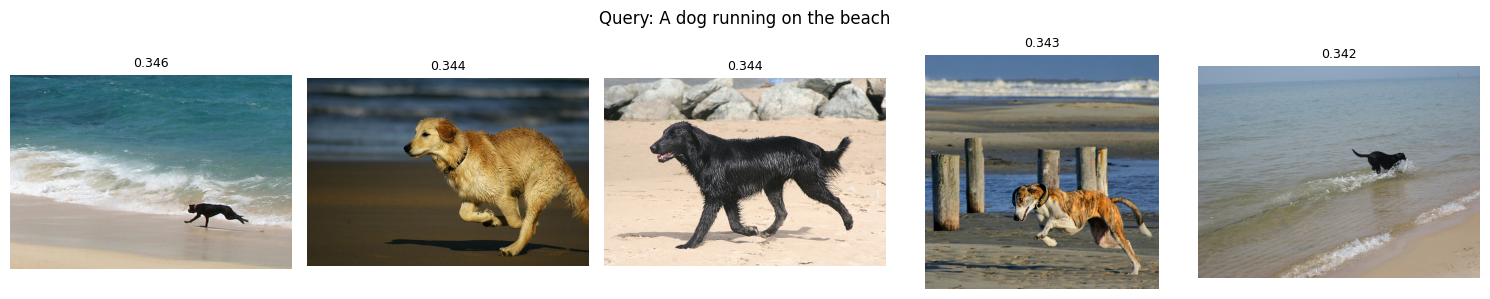

Encoding texts: 100%|██████████| 1/1 [00:00<00:00, 117.58it/s]


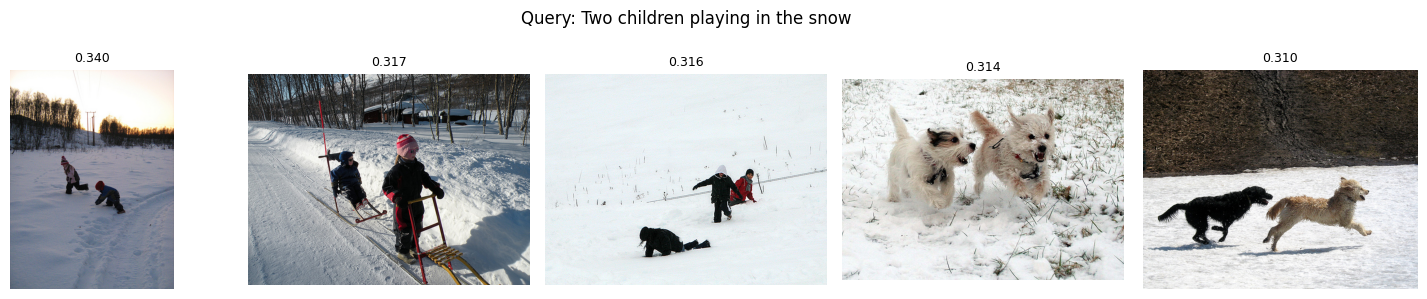

Encoding texts: 100%|██████████| 1/1 [00:00<00:00, 90.92it/s]


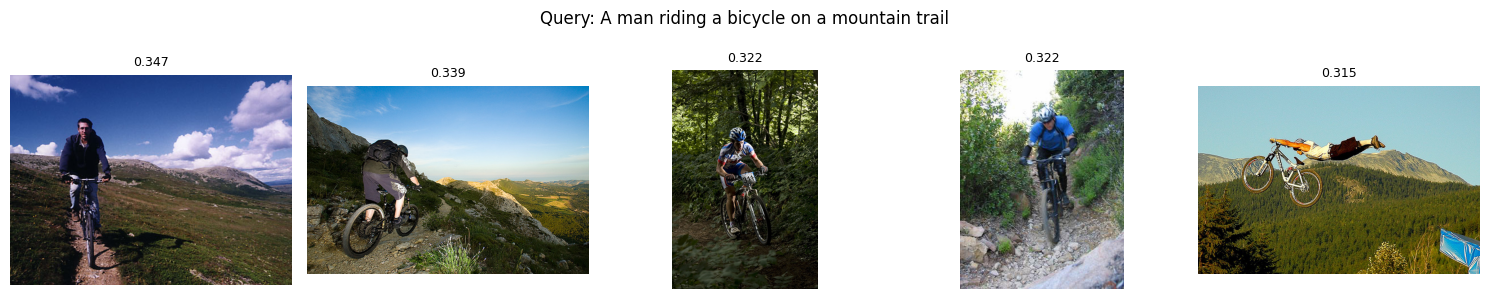

In [8]:
def text_to_image_search(query_text, k=5):
    q = encode_texts([query_text])
    scores, idx = image_index.search(q, k)
    return scores[0], idx[0]

def show_images(image_names, scores=None, title=""):
    n = len(image_names)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]
    for i, name in enumerate(image_names):
        img = Image.open(os.path.join(IMAGES_DIR, name)).convert("RGB")
        axes[i].imshow(img)
        axes[i].axis("off")
        if scores is not None:
            axes[i].set_title(f"{scores[i]:.3f}", fontsize=9)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

text_queries = [
    "A dog running on the beach",
    "Two children playing in the snow",
    "A man riding a bicycle on a mountain trail",
]

for q in text_queries:
    scores, idxs = text_to_image_search(q, k=5)
    retrieved = [all_images[i] for i in idxs]
    show_images(retrieved, scores, title=f"Query: {q}")

## 8. Recherche image → texte

Encoding images: 100%|██████████| 1/1 [00:00<00:00, 26.30it/s]


=== Image requête : 1000268201_693b08cb0e.jpg ===


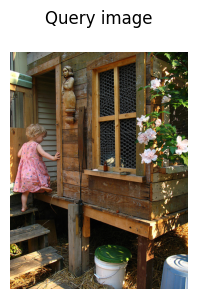

  [0.346] A little girl in a pink dress going into a wooden cabin .
  [0.346] A little girl climbing the stairs to her playhouse .
  [0.339] A little girl climbing into a wooden playhouse .
  [0.332] A baby girl wearing a pink jacket climbs wooden steps .
  [0.331] A child in a pink dress is climbing up a set of stairs in an entry way .


Encoding images: 100%|██████████| 1/1 [00:00<00:00, 58.76it/s]


=== Image requête : 1001773457_577c3a7d70.jpg ===


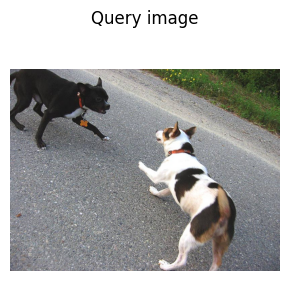

  [0.365] A black and brown dogs pulling a red leash .
  [0.363] A brown and black dog on a leash is sniffed by a black and white dog .
  [0.356] A black dog and a tri-colored dog playing with each other on the road .
  [0.351] A small black and brown dog on a leash is jumping on a bigger tri-colored dog on a leash .
  [0.345] A large brown dog and a large black and white dog running together


Encoding images: 100%|██████████| 1/1 [00:00<00:00, 44.42it/s]


=== Image requête : 1002674143_1b742ab4b8.jpg ===


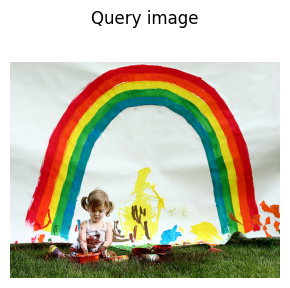

  [0.370] A small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .
  [0.370] A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
  [0.363] A little girl is sitting in front of a large painted rainbow .
  [0.329] A child covered with paint sits amid trays of multicolored paint on a surface thoroughly saturated with paint .
  [0.325] A young girl in front of a rainbow .


In [9]:
def image_to_text_search(image_name, k=5):
    q = encode_images([image_name])
    scores, idx = text_index.search(q, k)
    return scores[0], idx[0]

image_queries = all_images[:3]

for img_name in image_queries:
    scores, idxs = image_to_text_search(img_name, k=5)
    print(f"\n=== Image requête : {img_name} ===")
    show_images([img_name], title="Query image")
    for s, i in zip(scores, idxs):
        print(f"  [{s:.3f}] {all_captions[i]}")

## 9. Évaluation : Précision, Rappel, mAP

**Protocole standard pour Flickr8K :**
- Chaque image possède 5 légendes ground-truth.
- **Text → Image :** pour chaque légende, la seule image pertinente est celle dont elle provient. Rappel@K = 1 si l'image correcte est dans le top-K.
- **Image → Text :** pour chaque image, les 5 légendes associées sont pertinentes.

Nous évaluons sur un sous-ensemble aléatoire pour garder un temps de calcul raisonnable.

In [10]:
image_to_idx = {name: i for i, name in enumerate(all_images)}

gt_captions_for_image = {img: [] for img in all_images}
for i, row in df_captions.iterrows():
    gt_captions_for_image[row["image"]].append(i)

gt_image_for_caption = df_captions["image"].map(image_to_idx).values

In [11]:
def average_precision(retrieved_idx, relevant_set):
    hits = 0
    sum_prec = 0.0
    for rank, idx in enumerate(retrieved_idx, start=1):
        if idx in relevant_set:
            hits += 1
            sum_prec += hits / rank
    if not relevant_set:
        return 0.0
    return sum_prec / len(relevant_set)

def evaluate_text_to_image(n_queries=1000, k=10):
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(all_captions), size=min(n_queries, len(all_captions)), replace=False)
    q_embs = text_embeddings[sample_idx]
    _, retrieved = image_index.search(q_embs, k)

    recall_at_1 = 0
    recall_at_5 = 0
    recall_at_10 = 0
    aps = []
    for i, q_idx in enumerate(sample_idx):
        gt_img = gt_image_for_caption[q_idx]
        retr = retrieved[i]
        if gt_img == retr[0]:
            recall_at_1 += 1
        if gt_img in retr[:5]:
            recall_at_5 += 1
        if gt_img in retr[:10]:
            recall_at_10 += 1
        aps.append(average_precision(retr, {gt_img}))

    n = len(sample_idx)
    return {
        "R@1": recall_at_1 / n,
        "R@5": recall_at_5 / n,
        "R@10": recall_at_10 / n,
        "mAP": float(np.mean(aps)),
    }

def evaluate_image_to_text(n_queries=1000, k=10):
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(all_images), size=min(n_queries, len(all_images)), replace=False)
    q_embs = image_embeddings[sample_idx]
    _, retrieved = text_index.search(q_embs, k)

    recall_at_1 = 0
    recall_at_5 = 0
    recall_at_10 = 0
    precisions_at_5 = []
    aps = []
    for i, img_idx in enumerate(sample_idx):
        img_name = all_images[img_idx]
        relevant = set(gt_captions_for_image[img_name])
        retr = retrieved[i]
        if retr[0] in relevant:
            recall_at_1 += 1
        if any(r in relevant for r in retr[:5]):
            recall_at_5 += 1
        if any(r in relevant for r in retr[:10]):
            recall_at_10 += 1
        p5 = sum(1 for r in retr[:5] if r in relevant) / 5
        precisions_at_5.append(p5)
        aps.append(average_precision(retr, relevant))

    n = len(sample_idx)
    return {
        "R@1": recall_at_1 / n,
        "R@5": recall_at_5 / n,
        "R@10": recall_at_10 / n,
        "P@5": float(np.mean(precisions_at_5)),
        "mAP": float(np.mean(aps)),
    }

print("=== Text -> Image ===")
t2i = evaluate_text_to_image(n_queries=1000, k=10)
for k, v in t2i.items():
    print(f"  {k}: {v:.4f}")

print("\n=== Image -> Text ===")
i2t = evaluate_image_to_text(n_queries=1000, k=10)
for k, v in i2t.items():
    print(f"  {k}: {v:.4f}")

=== Text -> Image ===
  R@1: 0.2790
  R@5: 0.5410
  R@10: 0.6560
  mAP: 0.3902

=== Image -> Text ===
  R@1: 0.4860
  R@5: 0.7180
  R@10: 0.7990
  P@5: 0.3152
  mAP: 0.3021


### Courbe Précision-Rappel (text → image)

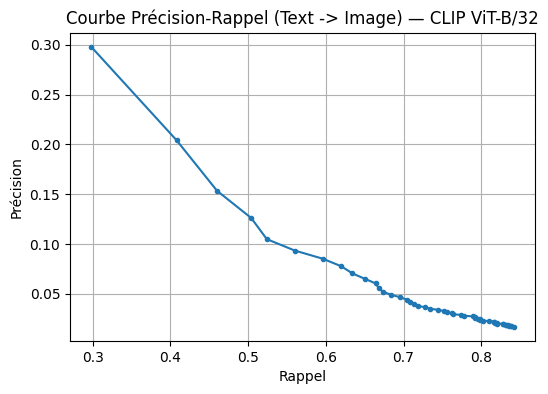

In [12]:
def pr_curve_text_to_image(n_queries=500, k=50):
    rng = np.random.default_rng(0)
    sample_idx = rng.choice(len(all_captions), size=min(n_queries, len(all_captions)), replace=False)
    q_embs = text_embeddings[sample_idx]
    _, retrieved = image_index.search(q_embs, k)

    precisions = np.zeros(k)
    recalls = np.zeros(k)
    for i, q_idx in enumerate(sample_idx):
        gt_img = gt_image_for_caption[q_idx]
        for rank in range(k):
            hit = int(gt_img in retrieved[i, :rank + 1])
            precisions[rank] += hit / (rank + 1)
            recalls[rank] += hit
    precisions /= len(sample_idx)
    recalls /= len(sample_idx)
    return precisions, recalls

prec, rec = pr_curve_text_to_image()
plt.figure(figsize=(6, 4))
plt.plot(rec, prec, marker="o", markersize=3)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe Précision-Rappel (Text -> Image) — CLIP ViT-B/32")
plt.grid(True)
plt.show()

## 10. (Optionnel) Comparaison avec un second modèle contrastif : OpenCLIP

On réencode tout le dataset avec **OpenCLIP ViT-B/32 entraîné sur LAION-2B** (`laion/CLIP-ViT-B-32-laion2B-s34B-b79K`), disponible directement via `transformers`. On compare ensuite les performances aux mêmes métriques que la section 9.

In [13]:
MODEL_NAME_2 = "laion/CLIP-ViT-B-32-laion2B-s34B-b79K"

model2 = CLIPModel.from_pretrained(MODEL_NAME_2).to(device).eval()
processor2 = CLIPProcessor.from_pretrained(MODEL_NAME_2)
EMBED_DIM_2 = model2.config.projection_dim
print(f"Modèle 2 chargé : {MODEL_NAME_2}")
print(f"Dimension des embeddings : {EMBED_DIM_2}")

config.json: 0.00B [00:00, ?B/s]

c:\Users\flavi\Desktop\MA1\Q2\MultimediaRetrieval\Projet\Machine-and-DeepLearning-for-Multimedia-Retrieval\.venv\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\flavi\.cache\huggingface\hub\models--laion--CLIP-ViT-B-32-laion2B-s34B-b79K. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Modèle 2 chargé : laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Dimension des embeddings : 512


In [14]:
def encode_images_m2(image_names, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(image_names), batch_size), desc="Encoding images (M2)"):
        batch_names = image_names[i:i + batch_size]
        images = [Image.open(os.path.join(IMAGES_DIR, n)).convert("RGB") for n in batch_names]
        inputs = processor2(images=images, return_tensors="pt").to(device)
        with torch.no_grad():
            feats = _to_tensor(model2.get_image_features(**inputs))
        feats = feats / feats.norm(dim=-1, keepdim=True)
        embeddings.append(feats.cpu().numpy())
    return np.vstack(embeddings).astype("float32")

def encode_texts_m2(texts, batch_size=64):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding texts (M2)"):
        batch = texts[i:i + batch_size]
        inputs = processor2(text=batch, return_tensors="pt", padding=True, truncation=True).to(device)
        with torch.no_grad():
            feats = _to_tensor(model2.get_text_features(**inputs))
        feats = feats / feats.norm(dim=-1, keepdim=True)
        embeddings.append(feats.cpu().numpy())
    return np.vstack(embeddings).astype("float32")

image_embeddings_2 = encode_images_m2(all_images)
text_embeddings_2 = encode_texts_m2(all_captions)
print(f"Image embeddings M2 : {image_embeddings_2.shape}")
print(f"Text embeddings  M2 : {text_embeddings_2.shape}")

Encoding texts (M2): 100%|██████████| 633/633 [00:23<00:00, 27.30it/s]

Image embeddings M2 : (8091, 512)
Text embeddings  M2 : (40455, 512)


In [15]:
image_index_2 = faiss.IndexFlatIP(EMBED_DIM_2)
image_index_2.add(image_embeddings_2)

text_index_2 = faiss.IndexFlatIP(EMBED_DIM_2)
text_index_2.add(text_embeddings_2)

print(f"Index M2 — images : {image_index_2.ntotal} | textes : {text_index_2.ntotal}")

Index M2 — images : 8091 | textes : 40455


### Réévaluation avec le modèle 2

On généralise les fonctions d'évaluation pour qu'elles prennent en paramètres les embeddings et les index à utiliser.

In [16]:
def eval_t2i(text_embs, img_index, n_queries=1000, k=10):
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(all_captions), size=min(n_queries, len(all_captions)), replace=False)
    q_embs = text_embs[sample_idx]
    _, retrieved = img_index.search(q_embs, k)
    r1 = r5 = r10 = 0
    aps = []
    for i, q_idx in enumerate(sample_idx):
        gt = gt_image_for_caption[q_idx]
        retr = retrieved[i]
        if gt == retr[0]: r1 += 1
        if gt in retr[:5]: r5 += 1
        if gt in retr[:10]: r10 += 1
        aps.append(average_precision(retr, {gt}))
    n = len(sample_idx)
    return {"R@1": r1/n, "R@5": r5/n, "R@10": r10/n, "mAP": float(np.mean(aps))}

def eval_i2t(img_embs, txt_index, n_queries=1000, k=10):
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(all_images), size=min(n_queries, len(all_images)), replace=False)
    q_embs = img_embs[sample_idx]
    _, retrieved = txt_index.search(q_embs, k)
    r1 = r5 = r10 = 0
    p5s, aps = [], []
    for i, img_idx in enumerate(sample_idx):
        relevant = set(gt_captions_for_image[all_images[img_idx]])
        retr = retrieved[i]
        if retr[0] in relevant: r1 += 1
        if any(r in relevant for r in retr[:5]): r5 += 1
        if any(r in relevant for r in retr[:10]): r10 += 1
        p5s.append(sum(1 for r in retr[:5] if r in relevant) / 5)
        aps.append(average_precision(retr, relevant))
    n = len(sample_idx)
    return {"R@1": r1/n, "R@5": r5/n, "R@10": r10/n, "P@5": float(np.mean(p5s)), "mAP": float(np.mean(aps))}

t2i_m1 = eval_t2i(text_embeddings,   image_index)
t2i_m2 = eval_t2i(text_embeddings_2, image_index_2)
i2t_m1 = eval_i2t(image_embeddings,   text_index)
i2t_m2 = eval_i2t(image_embeddings_2, text_index_2)

In [17]:
comparison = pd.DataFrame({
    "Model": ["CLIP ViT-B/32 (OpenAI)", "OpenCLIP ViT-B/32 (LAION-2B)"],
    "T2I R@1":  [t2i_m1["R@1"],  t2i_m2["R@1"]],
    "T2I R@5":  [t2i_m1["R@5"],  t2i_m2["R@5"]],
    "T2I R@10": [t2i_m1["R@10"], t2i_m2["R@10"]],
    "T2I mAP":  [t2i_m1["mAP"],  t2i_m2["mAP"]],
    "I2T R@1":  [i2t_m1["R@1"],  i2t_m2["R@1"]],
    "I2T R@5":  [i2t_m1["R@5"],  i2t_m2["R@5"]],
    "I2T P@5":  [i2t_m1["P@5"],  i2t_m2["P@5"]],
    "I2T mAP":  [i2t_m1["mAP"],  i2t_m2["mAP"]],
})
comparison.round(4)

,Model,T2I R@1,T2I R@5,T2I R@10,T2I mAP,I2T R@1,I2T R@5,I2T P@5,I2T mAP
0,CLIP ViT-B/32 (OpenAI),0.279,0.541,0.656,0.3902,0.486,0.718,0.3152,0.3021
1,OpenCLIP ViT-B/32 (LAION-2B),0.388,0.640,0.735,0.4953,0.544,0.778,0.3878,0.3798


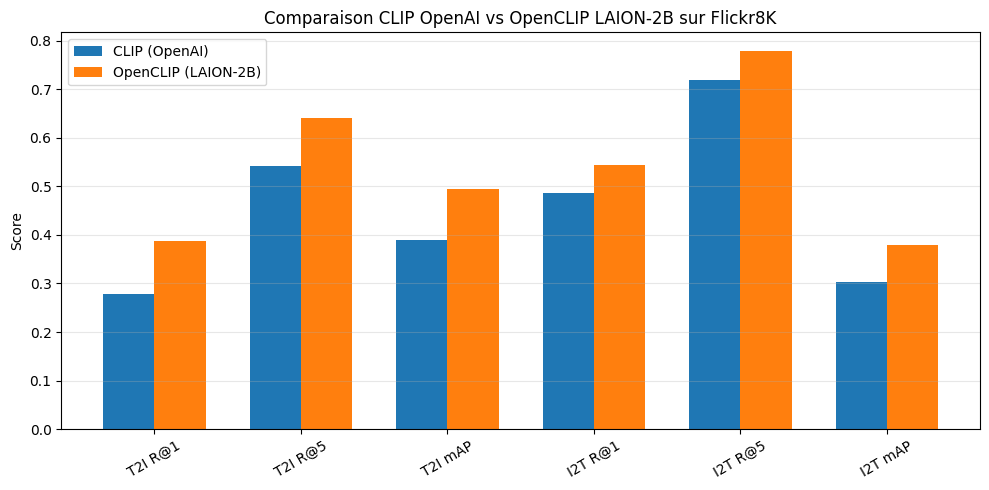

In [18]:
metrics = ["T2I R@1", "T2I R@5", "T2I mAP", "I2T R@1", "I2T R@5", "I2T mAP"]
x = np.arange(len(metrics))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, comparison.iloc[0][metrics].values, w, label="CLIP (OpenAI)")
ax.bar(x + w/2, comparison.iloc[1][metrics].values, w, label="OpenCLIP (LAION-2B)")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=30)
ax.set_ylabel("Score")
ax.set_title("Comparaison CLIP OpenAI vs OpenCLIP LAION-2B sur Flickr8K")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Comparaison qualitative sur les mêmes requêtes

Affichage côte à côte des top-5 images retournées par chaque modèle pour les mêmes requêtes textuelles.

Encoding texts (M2): 100%|██████████| 1/1 [00:00<00:00, 100.01it/s]


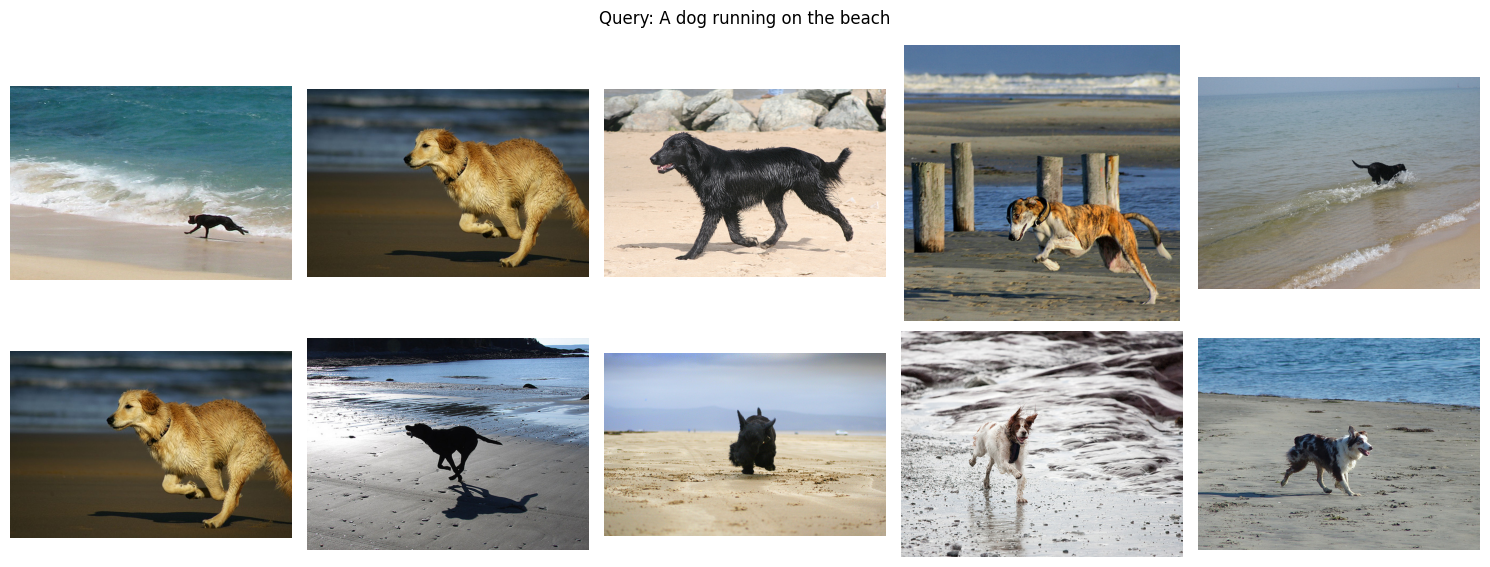

Encoding texts (M2): 100%|██████████| 1/1 [00:00<00:00, 100.00it/s]


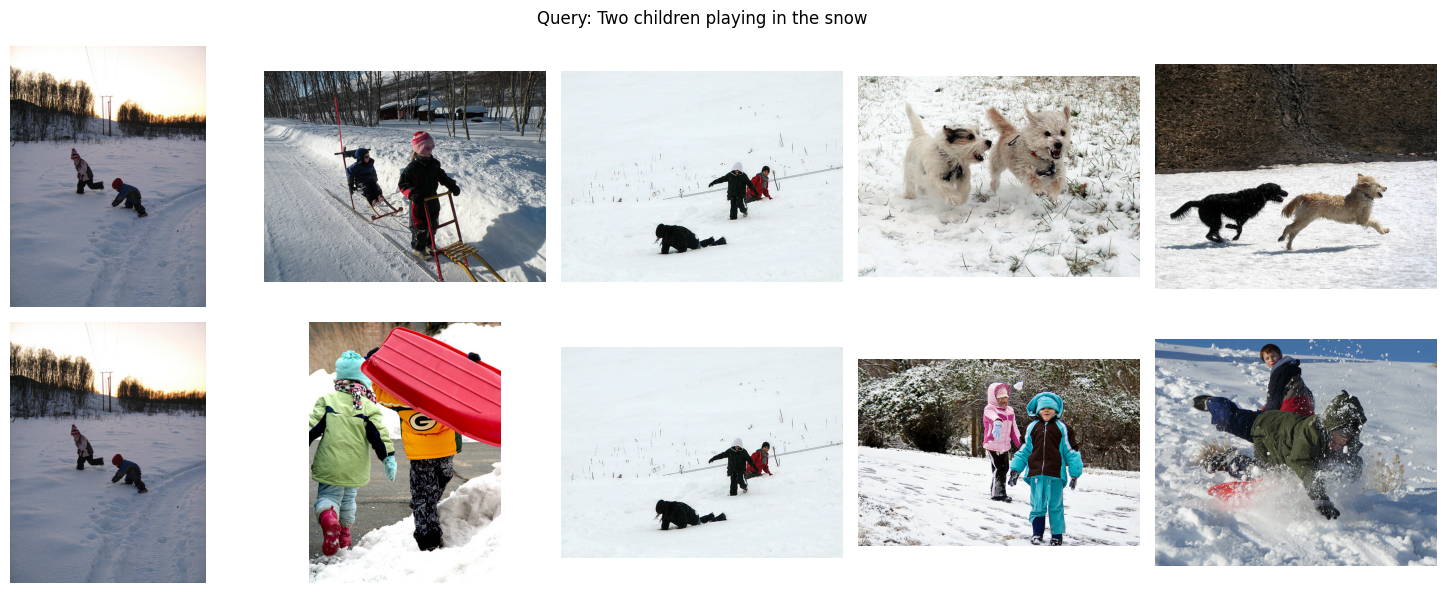

Encoding texts (M2): 100%|██████████| 1/1 [00:00<00:00, 90.64it/s]


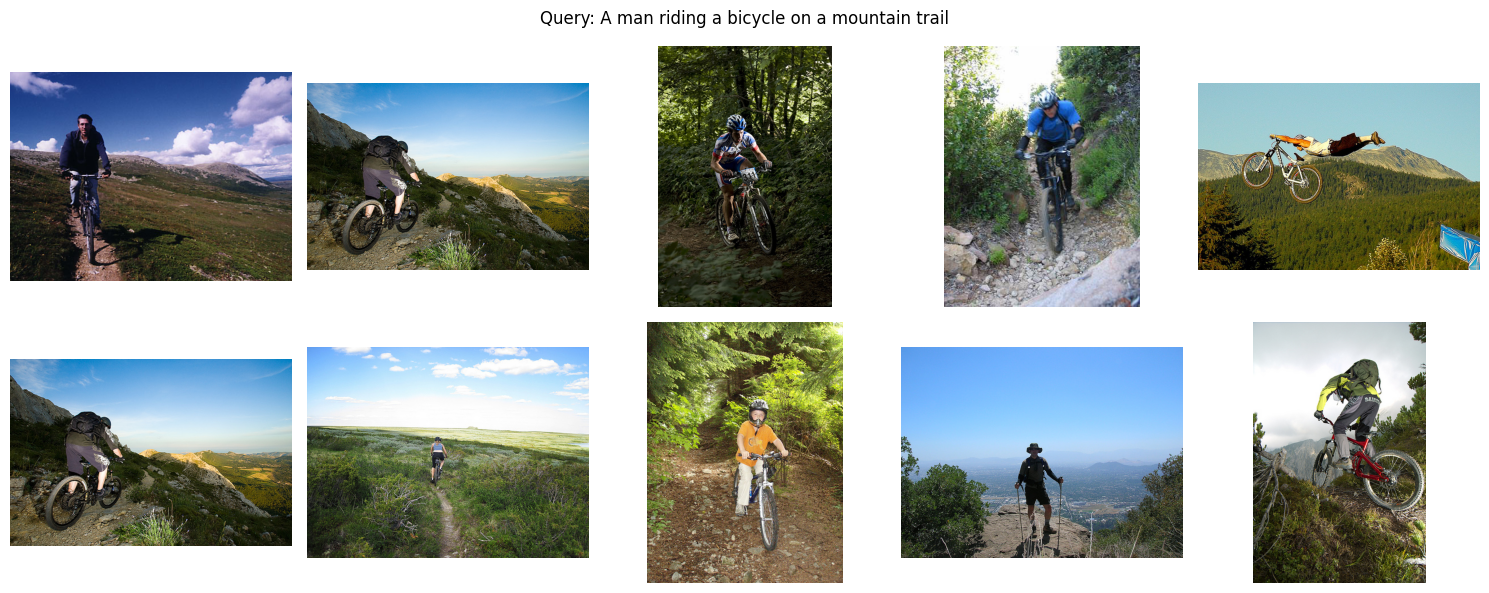

In [19]:
def compare_text_to_image(query, k=5):
    q1 = encode_texts([query])
    q2 = encode_texts_m2([query])
    _, idx1 = image_index.search(q1, k)
    _, idx2 = image_index_2.search(q2, k)
    retr1 = [all_images[i] for i in idx1[0]]
    retr2 = [all_images[i] for i in idx2[0]]

    fig, axes = plt.subplots(2, k, figsize=(3*k, 6))
    for j, name in enumerate(retr1):
        axes[0, j].imshow(Image.open(os.path.join(IMAGES_DIR, name)).convert("RGB"))
        axes[0, j].axis("off")
    for j, name in enumerate(retr2):
        axes[1, j].imshow(Image.open(os.path.join(IMAGES_DIR, name)).convert("RGB"))
        axes[1, j].axis("off")
    axes[0, 0].set_ylabel("CLIP OpenAI", fontsize=11)
    axes[1, 0].set_ylabel("OpenCLIP LAION", fontsize=11)
    fig.suptitle(f"Query: {query}", fontsize=12)
    plt.tight_layout()
    plt.show()

for q in text_queries:
    compare_text_to_image(q, k=5)

### Analyse et pistes d'amélioration proposées

**Observations attendues :**
- OpenCLIP LAION-2B est entraîné sur un corpus beaucoup plus vaste (2 milliards de paires) que le CLIP d'OpenAI (~400M). Sur la plupart des benchmarks zero-shot, il obtient de meilleurs scores.
- Sur Flickr8K, les deux modèles devraient donner des R@1 > 50 % en text→image, ce qui est élevé car le dataset est petit et les concepts génériques.
- Les écarts qualitatifs se voient surtout sur les requêtes rares ou composées (attributs multiples, relations spatiales).

**Améliorations proposées pour le moteur :**
1. **Reranking en deux étapes :** récupérer le top-50 avec CLIP (rapide) puis réordonner avec BLIP-ITM (plus lourd mais plus précis sur le matching fin).
2. **Prompt engineering :** préfixer les requêtes textuelles par `"a photo of ..."` améliore souvent le retrieval (technique standard CLIP).
3. **Réduction de dimension par PCA** (512 → 128) pour diviser la taille de l'index et accélérer FAISS, avec une perte marginale de mAP (~1-2 points).
4. **Index approximatif** (`IndexHNSWFlat` ou `IndexIVFFlat`) pour passer à l'échelle sur Flickr30K / COCO sans perte significative.
5. **Fine-tuning contrastif léger** sur le train-split de Flickr8K (loss InfoNCE, quelques époques, LR faible) pour spécialiser le modèle au domaine photographique du dataset.

## Conclusion

- Les images et les textes de Flickr8K ont été projetés dans un espace commun via CLIP, puis indexés avec FAISS (`IndexFlatIP`, similarité cosinus après L2-normalisation).
- Les deux sens de recherche fonctionnent : **texte → image** et **image → texte**.
- L'évaluation quantitative utilise R@1, R@5, R@10, P@5 et mAP, conformément aux métriques demandées dans l'énoncé.

### Pistes d'amélioration (bonus du sujet)
- Fine-tuning de CLIP sur Flickr8K.
- Réduction de dimension (PCA) des embeddings pour accélérer la recherche.
- Utilisation d'un index FAISS approximatif (`IndexIVFFlat`, `IndexHNSWFlat`) pour passer à l'échelle.
- Reranking avec un modèle plus lourd (BLIP-ITM) sur le top-K de CLIP.